In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import requests
import io

In [11]:
url = "https://en.wikipedia.org/wiki/NIFTY_500"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                  "(KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36"
}

response = requests.get(url, headers=headers, timeout=30)
print("status:", response.status_code)
print("final url:", response.url)
print("has <table>:", "<table" in response.text.lower())

response.raise_for_status()

# Try all wiki tables
tables = pd.read_html(io.StringIO(response.text), attrs={"class": "wikitable"})
print("tables found:", len(tables))

# Pick the table that contains Symbol + Industry (more stable than tables[4])
nifty500_df = None
for t in tables:
    cols = [str(c).strip() for c in t.columns]
    if "Symbol" in cols and "Industry" in cols:
        nifty500_df = t.copy()
        break

if nifty500_df is None:
    raise ValueError("Constituents table not found. Check page content/parsers.")

display(nifty500_df.head())

status: 403
final url: https://en.wikipedia.org/wiki/NIFTY_500
has <table>: False


HTTPError: 403 Client Error: Too many requests. Please respect our robot policy https://w.wiki/4wJS. (dd12474) for url: https://en.wikipedia.org/wiki/NIFTY_500

In [6]:
url = 'https://en.wikipedia.org/wiki/NIFTY_500#Constituents'

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

response = requests.get(url, headers=headers)

html_content = io.StringIO(response.text)
tables = pd.read_html(html_content)

ValueError: No tables found

In [3]:
nifty500_df = tables[4]

In [4]:
header = nifty500_df.iloc[0]
nifty500_df = nifty500_df[1:]
nifty500_df.columns = header
nifty500_df = nifty500_df.reset_index(drop=True)

In [5]:
nifty500_df

,Sl.No,Company Name,Industry,Symbol,Series,ISIN Code
0,1,360 ONE WAM Ltd.,Financial Services,360ONE,EQ,INE466L01038
1,2,3M India Ltd.,Diversified,3MINDIA,EQ,INE470A01017
2,3,ABB India Ltd.,Capital Goods,ABB,EQ,INE117A01022
3,4,ACC Ltd.,Construction Materials,ACC,EQ,INE012A01025
4,5,AIA Engineering Ltd.,Capital Goods,AIAENG,EQ,INE212H01026
...,...,...,...,...,...,...
495,496,Zee Entertainment Enterprises Ltd.,Media Entertainment & Publication,ZEEL,EQ,INE256A01028
496,497,Zensar Technologies Ltd.,Information Technology,ZENSARTECH,EQ,INE520A01027
497,498,Eternal Ltd.,Consumer Services,ETERNAL,EQ,INE758T01015
498,499,Zydus Lifesciences Ltd.,Healthcare,ZYDUSLIFE,EQ,INE010B01027


In [6]:
nifty500_df['Industry'].value_counts()

,count
Industry,
Financial Services,92
Capital Goods,61
Healthcare,46
Chemicals,34
Automobile and Auto Components,33
Fast Moving Consumer Goods,31
Information Technology,25
Consumer Durables,25
Consumer Services,25


In [7]:
nifty500_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Sl.No         500 non-null    object
 1   Company Name  500 non-null    object
 2   Industry      500 non-null    object
 3   Symbol        500 non-null    object
 4   Series        500 non-null    object
 5   ISIN Code     500 non-null    object
dtypes: object(6)
memory usage: 23.6+ KB


In [7]:
tickers = nifty500_df['Symbol'].astype('str') + '.NS'
ticker_list = tickers.tolist()

In [8]:
raw_data = yf.download(ticker_list, period='5y', interval='1d')

/tmp/ipykernel_14313/3014736257.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(ticker_list, period='5y', interval='1d')
[*                      2%                       ]  12 of 500 completedERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: SUVENPHAR.NS"}}}
[*****                 11%                       ]  55 of 500 completedERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: SWANENERGY.NS"}}}
[*********************100%***********************]  500 of 500 completed
ERROR:yfinance:
6 Failed downloads:
ERROR:yfinance:['SUVENPHAR.NS', 'SWANENERGY.NS', 'PEL.NS', 'TATAMOTORS.NS', 'GMRINFRASTRUCT.NS', 'ISEC.NS']: YFPricesMissingError('possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")')


In [9]:
closing_prices = raw_data['Close']

In [10]:
pd.set_option('display.max_rows', None)
nan_counts = closing_prices.isna().sum()

In [11]:
nan_counts[nan_counts > 1].count()

np.int64(70)

In [12]:
pd.set_option('display.max_rows', False)
closing_prices

Ticker,360ONE.NS,3MINDIA.NS,AARTIIND.NS,AAVAS.NS,ABB.NS,ABBOTINDIA.NS,ABCAPITAL.NS,ABFRL.NS,ABREL.NS,ACC.NS,...,WELCORP.NS,WELSPUNLIV.NS,WESTLIFE.NS,WHIRLPOOL.NS,WIPRO.NS,YESBANK.NS,ZEEL.NS,ZENSARTECH.NS,ZFCVINDIA.NS,ZYDUSLIFE.NS
Date,,,,,,,,,,,,,,,,,,,,,
2021-04-12,259.869537,23742.001953,664.035095,2171.550049,1281.015015,14013.589844,113.500000,172.899994,448.551636,1813.017090,...,134.896683,76.413399,401.988678,2123.658691,199.839417,14.450000,171.559036,251.833496,6005.512695,481.951965
2021-04-13,262.041138,24321.187500,675.220703,2295.399902,1290.944580,13929.972656,116.099998,176.500000,452.344177,1809.604004,...,135.671402,76.216835,402.137970,2150.502197,193.533798,14.700000,178.142883,254.871078,6048.529297,472.548248
2021-04-15,252.682526,23719.751953,674.580078,2327.600098,1320.146362,13892.585938,119.650002,171.600006,454.412781,1765.857666,...,132.390152,76.315117,405.074036,2105.040039,198.961716,14.550000,179.232300,251.412979,6025.431152,486.774353
2021-04-16,261.886841,25113.023438,702.297424,2316.050049,1341.570801,13934.581055,120.099998,173.750000,465.150116,1809.219360,...,129.473465,79.804085,409.602509,2106.370117,216.746765,14.600000,183.732040,252.674698,6280.152344,508.378723
2021-04-19,247.413483,25522.576172,690.003296,2236.600098,1369.848511,13711.058594,115.550003,164.550003,442.148712,1804.412109,...,125.599731,75.774567,398.405731,2103.661133,218.386673,14.200000,180.321716,245.851944,6401.552246,508.427032
2021-04-20,243.467285,24629.386719,706.954041,2244.699951,1370.093994,13818.233398,117.300003,173.850006,438.454712,1755.425903,...,125.189590,75.578011,419.654694,2117.452637,217.162521,14.050000,187.000290,248.235321,6356.698242,536.493469
2021-04-22,235.795120,25086.828125,698.798889,2208.949951,1366.411865,14068.529297,117.250000,176.449997,441.311371,1761.050415,...,126.009888,77.445351,416.071747,2059.677002,224.807770,14.050000,182.168976,250.291367,6411.139648,532.924866
2021-04-23,241.461014,24505.224609,720.800476,2271.750000,1355.660400,14038.406250,116.099998,173.500000,453.674011,1743.023193,...,126.009888,77.150505,409.303925,2099.917969,219.749420,14.000000,178.095520,250.852158,6456.489258,550.623108
2021-04-26,244.812027,24322.351562,735.213501,2235.899902,1344.270874,14016.522461,113.050003,173.600006,463.130676,1773.645508,...,131.433105,77.985893,419.853760,2142.523193,221.874390,14.050000,176.579819,251.085815,6474.471680,549.321045


In [13]:
mask = closing_prices.isna().sum() <= 1
filtered_df = closing_prices.loc[:, mask]

In [14]:
filtered_df = filtered_df.ffill()

In [15]:
filtered_df.isna().sum().sum()

np.int64(0)

In [16]:
log_returns = np.log(filtered_df/filtered_df.shift(1)).dropna()

In [17]:
log_returns.describe()

Ticker,360ONE.NS,3MINDIA.NS,AARTIIND.NS,AAVAS.NS,ABB.NS,ABBOTINDIA.NS,ABCAPITAL.NS,ABFRL.NS,ABREL.NS,ACC.NS,...,WELCORP.NS,WELSPUNLIV.NS,WESTLIFE.NS,WHIRLPOOL.NS,WIPRO.NS,YESBANK.NS,ZEEL.NS,ZENSARTECH.NS,ZFCVINDIA.NS,ZYDUSLIFE.NS
count,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,...,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000
mean,0.001100,0.000228,-0.000358,-0.000457,0.001362,0.000493,0.000891,-0.000850,0.000908,-0.000193,...,0.001590,0.000387,0.000120,-0.000758,0.000014,0.000227,-0.000596,0.000653,0.000707,0.000520
std,0.023204,0.017734,0.021968,0.019986,0.020323,0.014676,0.021421,0.038602,0.026300,0.017864,...,0.027897,0.029134,0.020283,0.020091,0.016266,0.024103,0.031560,0.025329,0.019344,0.015810
min,-0.115613,-0.066112,-0.167822,-0.069056,-0.129643,-0.071765,-0.107759,-1.096384,-0.108606,-0.161787,...,-0.154802,-0.193509,-0.073546,-0.223112,-0.096783,-0.109761,-0.410050,-0.090744,-0.146916,-0.075268
25%,-0.011790,-0.009709,-0.010947,-0.011867,-0.009092,-0.007907,-0.010651,-0.012843,-0.014667,-0.009118,...,-0.014095,-0.015323,-0.012216,-0.009165,-0.008484,-0.010845,-0.015709,-0.013099,-0.009144,-0.008474
50%,-0.000064,-0.001399,-0.000251,-0.000883,0.001604,-0.000417,0.000447,-0.000726,-0.000975,0.000419,...,0.000252,-0.001600,-0.000635,-0.000810,0.000090,-0.000420,-0.001194,-0.000292,-0.000723,0.000448
75%,0.013571,0.008109,0.011198,0.009255,0.011240,0.007615,0.012689,0.011818,0.013433,0.008377,...,0.016085,0.012967,0.010672,0.008633,0.008626,0.009375,0.011805,0.013079,0.009561,0.009482
max,0.138649,0.156057,0.141509,0.096052,0.106401,0.080757,0.101994,0.139074,0.154193,0.096523,...,0.158994,0.180073,0.115858,0.111931,0.085617,0.159759,0.336319,0.178187,0.182322,0.078511


In [20]:
corr_matrix = log_returns.corr()

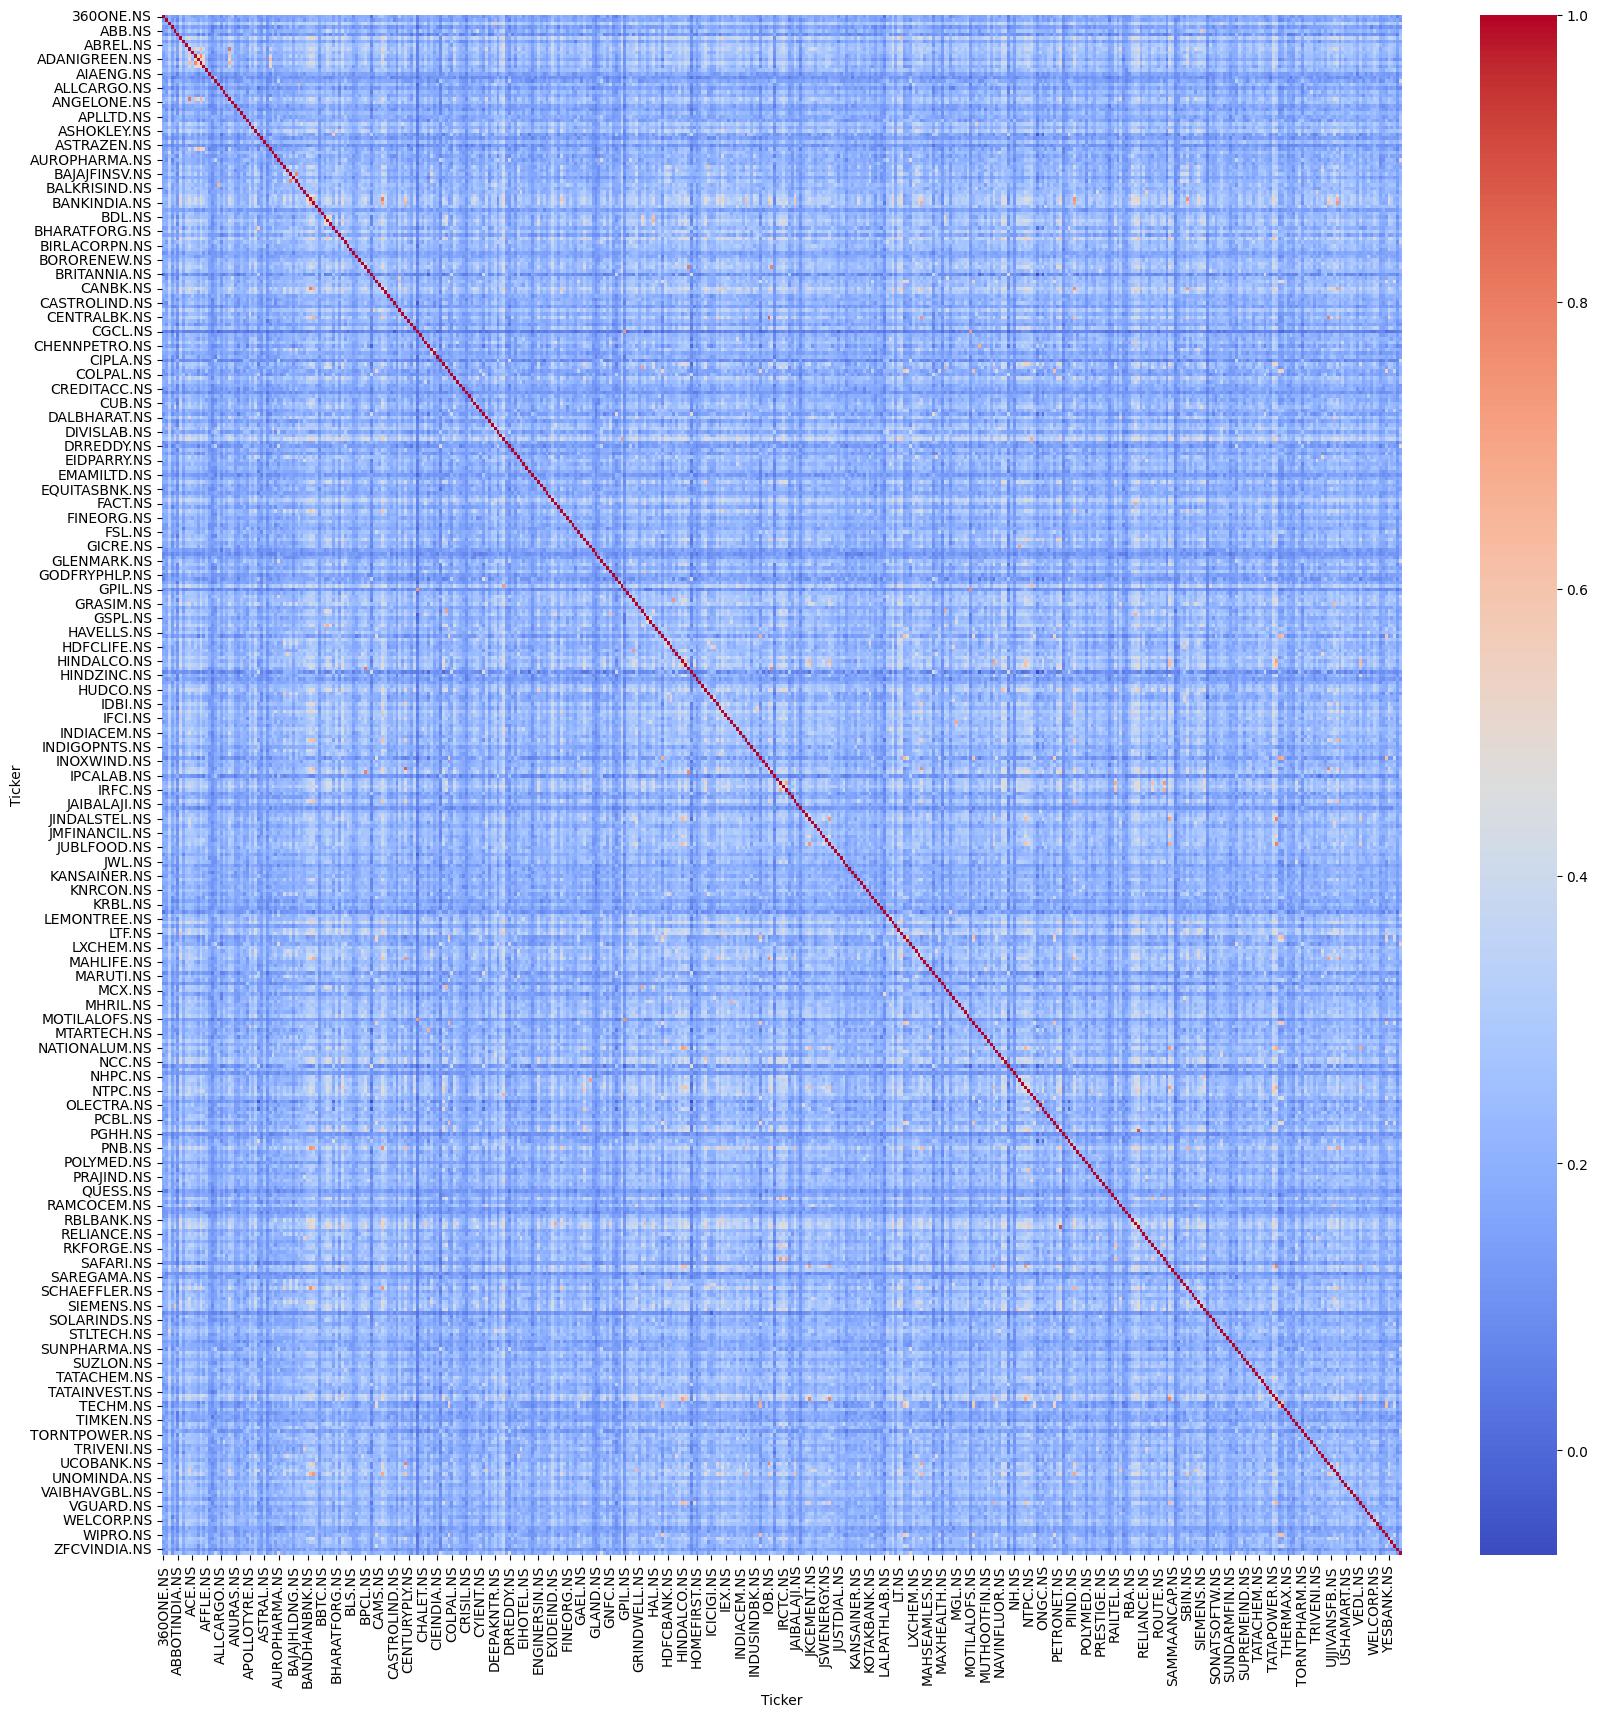

In [21]:
plt.figure(figsize=(20,20))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.show()

In [18]:
scaled_log_returns = StandardScaler().fit_transform(log_returns)

In [48]:
pca = PCA(n_components=10)

pca.fit(scaled_log_returns)

PCA(n_components=10)

In [49]:
pca.explained_variance_ratio_

array([0.23080649, 0.02337815, 0.01576277, 0.0138908 , 0.01131906,
       0.00940789, 0.00857802, 0.00778281, 0.00672484, 0.00632099])

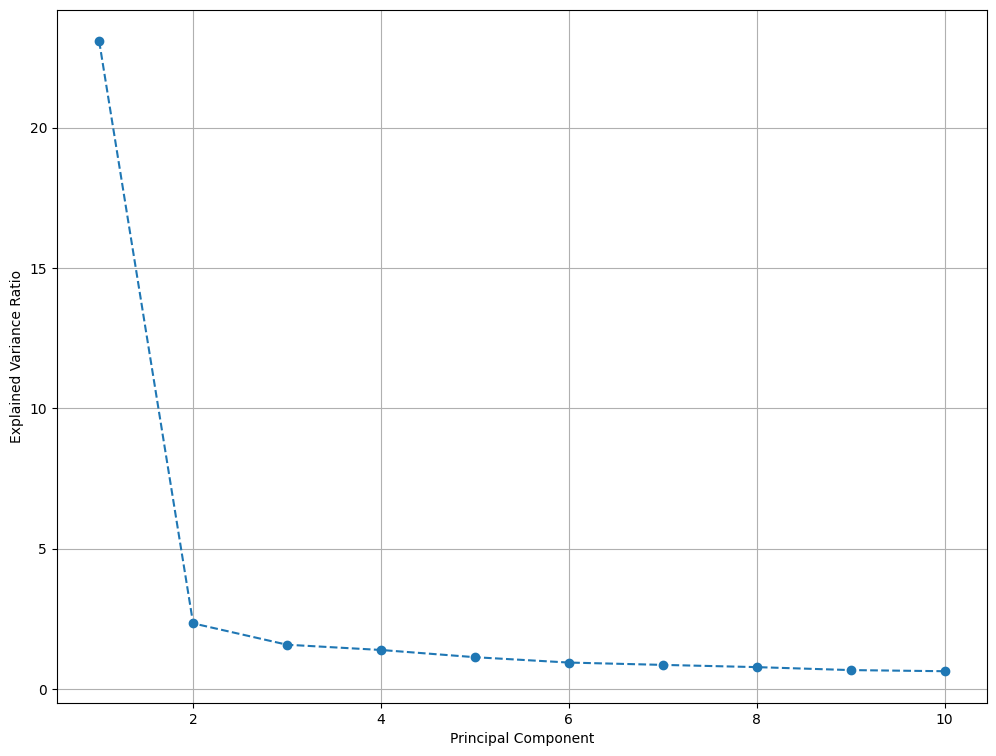

In [50]:
plt.figure(figsize=(12,9))
plt.plot(range(1,11), pca.explained_variance_ratio_*100, marker='o', linestyle='--')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

In [51]:
industry_map = (
    nifty500_df[['Symbol', 'Industry']].drop_duplicates('Symbol').set_index('Symbol')['Industry']
)

In [52]:
pc1_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[0] * 100
})

pc1_df['Industry'] = pc1_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc1_sorted = pc1_df.sort_values(by='Weight', ascending=False)

In [54]:
display(pc1_sorted.head(20)['Industry'].value_counts())
display(pc1_sorted.tail(20)['Industry'].value_counts())

,count
Industry,
Financial Services,9
Realty,2
Capital Goods,2
Metals & Mining,2
Power,1
Automobile and Auto Components,1
Chemicals,1
Construction,1
Consumer Services,1


,count
Industry,
Healthcare,10
Fast Moving Consumer Goods,5
Financial Services,2
Capital Goods,2
Services,1


In [55]:
# nifty500_df.columns = nifty500_df.columns.str.strip()

pc2_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[1] * 100
})

pc2_df['Industry'] = (pc2_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map))

pc2_sorted = pc2_df.sort_values(by='Weight', ascending=False)

In [56]:
pd.set_option('display.max_rows', None)
display(pc2_sorted.head(20)['Industry'].value_counts())
display(pc2_sorted.tail(20)['Industry'].value_counts())

,count
Industry,
Information Technology,10
Fast Moving Consumer Goods,6
Consumer Durables,1
Chemicals,1
Consumer Services,1
Healthcare,1


,count
Industry,
Financial Services,8
Oil Gas & Consumable Fuels,4
Construction,4
Power,3
Telecommunication,1


In [57]:
pc3_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[2] * 100
})

pc3_df['Industry'] = (pc3_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map))

pc3_sorted = pc3_df.sort_values(by='Weight', ascending=False)


In [59]:
display(pc3_sorted.head(20)['Industry'].value_counts())
display(pc3_sorted.tail(20)['Industry'].value_counts())

,count
Industry,
Financial Services,15
Automobile and Auto Components,2
Construction Materials,2
Capital Goods,1


,count
Industry,
Information Technology,17
Services,2
Healthcare,1


In [60]:
pc4_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[3] * 100
})

pc4_df['Industry'] = (pc4_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map))

pc4_sorted = pc4_df.sort_values(by='Weight', ascending=False)

In [61]:
display(pc4_sorted.head(20)['Industry'].value_counts())
display(pc4_sorted.tail(20)['Industry'].value_counts())

,count
Industry,
Information Technology,9
Metals & Mining,8
Oil Gas & Consumable Fuels,3


,count
Industry,
Fast Moving Consumer Goods,10
Consumer Durables,4
Automobile and Auto Components,3
Textiles,1
Capital Goods,1
Chemicals,1


In [87]:
path = r'C:\Users\Abhis\Downloads'

In [ ]:
pc1_sorted.to_csv(path + r'\pc1.csv', index=False)
pc2_sorted.to_csv(path + r'\pc2.csv', index=False)
pc3_sorted.to_csv(path + r'\pc3.csv', index=False)
pc4_sorted.to_csv(path + r'\pc4.csv', index=False)